In [1]:
# --- Core scientific stack ---
import numpy as np
import pandas as pd
import os
from pathlib import Path

# --- Visualization (for quick inspection & debugging) ---
import matplotlib.pyplot as plt
import seaborn as sns

# --- Utilities ---
import pickle
from pathlib import Path
from itertools import combinations
import json
import math
import warnings

In [2]:
# =============================================================================
# Config (absolute paths + environment)
# =============================================================================
REPO_ROOT = Path.cwd().parents[2]   # adjust the number as needed
print(REPO_ROOT)

/Users/titonka/FAIRIS


In [3]:
# Experiment selection
MAZES = ['LM4', 'LM6', 'LM8', 'LM8D', 'LMO8', 'LM8_addition', 'LMO8_remove', 'BR']
MAZE_INDEX = 4  # LM8D
MAZE_KEY = MAZES[MAZE_INDEX]

# Network sizes to evaluate
N_PCS_LIST = [10, 25, 50, 75, 100, 250, 500, 750]
# I/O
TRAIN_PATH      = REPO_ROOT / f"data/VisualPlaceCellData/{MAZE_KEY}_Training"
CLUSTER_DIR     = REPO_ROOT / "data/VisualPlaceCellData/VisualPlaceCellClusters"
FIG_PREFIX_DIR  = REPO_ROOT / "data/figures/ActivationMaps"
BG_IMAGE        = REPO_ROOT / f"data/DataCache/{MAZE_KEY}.png"
ACTIVATIONS_Data = REPO_ROOT / f"data/activations/activations_{MAZE_KEY}.pkl"



In [4]:
# Path to your saved activations pickle file
# (adjust the filename as needed)
pickle_path = Path(ACTIVATIONS_Data)

# Load the data
with open(pickle_path, "rb") as f:
    data = pickle.load(f)

# Confirm the structure
print(f"Loaded object type: {type(data)}")
print(f"Available keys in pickle: {list(data.keys())}")
print(f"Expected keys (N_PCS_LIST): {N_PCS_LIST}")

# Verify all expected keys exist in the pickle
missing = [k for k in N_PCS_LIST if k not in data]
if missing:
    print(f"️Missing expected entries for: {missing}")
else:
    print("All expected K values are present.")
    
# Select one configuration to inspect
example_K = N_PCS_LIST[-1]   # you can change index to inspect others
df = data[example_K]

print(f"\nInspecting DataFrame for K = {example_K}")
print(df.head())
print(f"\nShape: {df.shape}")

Loaded object type: <class 'dict'>
Available keys in pickle: [10, 25, 50, 75, 100, 250, 500, 750]
Expected keys (N_PCS_LIST): [10, 25, 50, 75, 100, 250, 500, 750]
All expected K values are present.

Inspecting DataFrame for K = 750
          x         y      pc_0      pc_1      pc_2      pc_3      pc_4  \
0 -0.080000 -2.359680  0.011306  0.000278  0.133842  0.004836  0.004827   
1  0.000150 -2.360148  0.011140  0.000305  0.134067  0.003758  0.006000   
2  0.080149 -2.360147  0.012568  0.000428  0.149241  0.002882  0.008225   
3 -0.119853 -2.320146  0.010632  0.000121  0.136406  0.003410  0.003883   
4 -0.039853 -2.320146  0.010511  0.000262  0.155738  0.003982  0.004662   

       pc_5      pc_6      pc_7  ...    pc_740    pc_741    pc_742    pc_743  \
0  0.002125  0.005982  0.003075  ...  0.021259  0.003568  0.115274  0.075451   
1  0.002613  0.006423  0.002973  ...  0.025365  0.004781  0.119637  0.081143   
2  0.003440  0.008124  0.002488  ...  0.031285  0.005511  0.126090  0.096810 

---
# Metric 1: Place Field Size
---

### 1. What We’re Measuring

For each **place cell**, we want to estimate the **area of the environment** where that cell is considered “active.”
That area is called the *place field* of the cell.

In your case:

* Each cell’s activation is evaluated at a fixed set of test points (the red dots in your grid).
* Those points sample the environment uniformly.
* The field size can therefore be approximated as:


$$ \text{FieldSize}*c = \text{(number of active sample points for cell c)} \times a_{\text{pix}} $$


where $(a_{\text{pix}})$ is the area represented by a single grid point.

---

### 2. Step 1 – Compute the Activation Matrix

From your DataFrame, you have:

* (K): the number of place cells for the configuration.
* (N): the number of sampled spatial positions (red dots).

So you form a matrix
$$
A \in \mathbb{R}^{K \times N}
$$
where $(A_{c,i})$ is the normalized activation of cell (c) at position (i).

---

### 3. Step 2 – Determine the Area Represented by One Sample Point

Because the grid is regular, each sample point corresponds to a small patch of equal size in the environment.

If the grid spacing along the x- and y-axes is $(\Delta x)$ and $(\Delta y)$, then

$$
a_{\text{pix}} = \Delta x \times \Delta y
$$

This gives the physical area that each red-dot position represents in square meters.
Multiplying by this area converts counts of “active points” into actual area.

---

### 4. Step 3 – Define an Activation Threshold for Each Cell

Each place cell has a different activation range, so we use a **relative threshold** instead of a global one.
Following standard practice (e.g., Muller et al., 1987), we define a threshold as a fixed fraction of that cell’s peak activation:

$$
\theta_c = \tau \cdot \max_i A_{c,i}
$$

where $(\tau)$ is typically 0.2 (20 % of the maximum).

This means: a cell is “active” at a location if its activation there is at least 20 % of its own maximum.

---

### 5. Step 4 – Determine the Active Locations

For each cell (c), we mark which spatial samples satisfy $(A_{c,i} \ge \theta_c)$.
This gives a binary mask for each cell, identifying all positions where it is active.

$$
\mathcal{F}*c = { i \mid A*{c,i} \ge \theta_c }
$$

The number of such positions is (|\mathcal{F}_c|).

---

### 6. Step 5 – Compute Field Size per Cell

The estimated place-field area for cell (c) is simply:

$$
\text{FieldSize}_c = |\mathcal{F}*c| \cdot a*{\text{pix}}
$$

So if a cell is active in 30 out of 400 sampled positions and each sample represents 0.01 m²,
then its field size is (30 \times 0.01 = 0.3) m².

---

### 7. Step 6 – Summarize Across the Population

Once we have all (K) field sizes, we compute summary statistics:

* **Median field size:** robust estimate of the typical field.
* **Interquartile range (IQR):** variability among cells.
* **Mean field size:** used later as the **Mean Activation Area (MAA)** in the Compression Index.

---

### 8. Why This Works

* Because all sample points are evenly spaced, counting active points directly corresponds to measuring spatial area.
* Normalizing activations to $[0, 1]$ per cell makes the threshold comparable across cells and configurations.
* Using a relative threshold (0.2 × peak) captures the main lobe of each cell’s response while excluding weak peripheral activity.

---

### 9. Expected Behavior

As the number of place cells (K) increases:

* Each cell’s field size should **decrease**, since more cells divide up the environment.
* The **total coverage** across all cells remains roughly constant (captured by later metrics).
* The **distribution of field sizes** often becomes narrower in simpler environments and broader in complex ones.

---


In [5]:
# --- Metric 1: Place-Field Size (per cell) ----------------------------------
# This cell:
#  1) extracts positions and activations for the selected K configuration
#  2) defines a_pix from a hard-coded occupiable area A_occ
#  3) applies a per-cell relative threshold (tau * max activation)
#  4) counts active samples per cell and converts to area (m^2)
#  5) assembles a tidy per-cell metrics DataFrame for downstream analysis

# ----------------------- Configuration / metadata ----------------------------
ENV_ID = "octagon_room"        # change as needed
THRESHOLD_FRAC = 0.20          # tau in the docs (per-cell threshold fraction)
A_OCC = 14.80                  # m^2 (hard-coded occupiable area for now; adjust as needed)

# ----------------------- Extract matrices from df ---------------------------
# positions: (N, 2) with columns ['x', 'y']
positions = df[['x', 'y']].to_numpy(dtype=float)    # shape: (N, 2)

# activations: collect all pc_* columns; A: (K, N)
pc_cols = [c for c in df.columns if c.startswith('pc_')]
A = df[pc_cols].to_numpy(dtype=float).T             # shape: (K, N)

# basic shapes
K = A.shape[0]
N = A.shape[1]

print(f"ENV_ID={ENV_ID}  K={K}  N={N}")

# ----------------------- Define per-sample area a_pix -----------------------
# Using the hard-coded occupiable area A_OCC and the number of samples N:
#   a_pix = A_occ / N
a_pix = A_OCC / float(N)
print(f"A_OCC={A_OCC:.4f} m^2   a_pix={a_pix:.6f} m^2 per sample")

# ----------------------- Thresholding and active mask -----------------------
# Per-cell threshold: theta_c = THRESHOLD_FRAC * max_i A[c, i]
# A is already column-normalized per your generator, so this is consistent.

with np.errstate(invalid='ignore'):
    per_cell_max = A.max(axis=1, keepdims=True)                     # (K, 1)
thresholds = THRESHOLD_FRAC * per_cell_max                          # (K, 1)
active_mask = A >= thresholds                                       # (K, N) bool

# ----------------------- Field sizes (per cell) -----------------------------
# FieldSize_c = |F_c| * a_pix, where F_c = { i | A[c,i] >= theta_c }
active_count = active_mask.sum(axis=1)                               # (K,)
field_size_m2 = active_count.astype(float) * a_pix                   # (K,)

# Optional diagnostics (useful later)
peak_activation = per_cell_max.ravel()                               # (K,)
mean_activation = A.mean(axis=1)                                     # (K,)

# ----------------------- Per-cell metrics DataFrame -------------------------

df_cells = pd.DataFrame({
    "env_id": ENV_ID,
    "K": K,
    "cell_id": np.arange(K, dtype=int),
    "threshold_frac": THRESHOLD_FRAC,
    "a_pix": a_pix,
    "A_occ": A_OCC,
    "active_count": active_count.astype(int),
    "field_size_m2": field_size_m2,
    "peak_activation": peak_activation,
    "mean_activation": mean_activation,
})

# Make it easy to preview by sorting (largest fields first)
df_cells = df_cells.sort_values("field_size_m2", ascending=False).reset_index(drop=True)

# ----------------------- Quick summary for sanity check ---------------------
median_fs = float(np.median(field_size_m2))
iqr_low, iqr_high = np.quantile(field_size_m2, [0.25, 0.75])
mean_fs = float(np.mean(field_size_m2))

print("\nPlace-Field Size summary (m^2):")
print(f"  median = {median_fs:.6f}")
print(f"  IQR    = [{iqr_low:.6f}, {iqr_high:.6f}]")
print(f"  mean   = {mean_fs:.6f}")

# Display the first few rows
df_cells.head(10)


ENV_ID=octagon_room  K=750  N=3772
A_OCC=14.8000 m^2   a_pix=0.003924 m^2 per sample

Place-Field Size summary (m^2):
  median = 0.227572
  IQR    = [0.109862, 0.387460]
  mean   = 0.324606


,env_id,K,cell_id,threshold_frac,a_pix,A_occ,active_count,field_size_m2,peak_activation,mean_activation
0,octagon_room,750,451,0.2,0.003924,14.8,3772,14.800000,0.0,0.000000
1,octagon_room,750,271,0.2,0.003924,14.8,746,2.927041,1.0,0.138041
2,octagon_room,750,262,0.2,0.003924,14.8,682,2.675928,1.0,0.108764
3,octagon_room,750,452,0.2,0.003924,14.8,572,2.244327,1.0,0.113533
4,octagon_room,750,397,0.2,0.003924,14.8,571,2.240403,1.0,0.114449
5,octagon_room,750,246,0.2,0.003924,14.8,490,1.922587,1.0,0.115906
6,octagon_room,750,193,0.2,0.003924,14.8,429,1.683245,1.0,0.104778
7,octagon_room,750,115,0.2,0.003924,14.8,427,1.675398,1.0,0.082682
8,octagon_room,750,304,0.2,0.003924,14.8,427,1.675398,1.0,0.104197
9,octagon_room,750,25,0.2,0.003924,14.8,409,1.604772,1.0,0.072632


---
# Metric 2: Coverage Index
---

## What the Coverage Index measures

Coverage asks: **What fraction of the environment is represented by at least one place cell?**
Operationally, for each sampled location (red dot), we check whether **any** cell is “active” there under the same per-cell thresholding rule you used for Metric #1.

Mathematically, with per-cell thresholds $\theta_c = \tau \cdot \max_i A_{c,i}$ and activity matrix $A \in \mathbb{R}^{K \times N}$:
$$
\text{Coverage} = \frac{1}{N}\sum_{i=1}^{N} \mathbb{1}!\left[ \max_{c} A_{c,i} \ge \theta_c \right].
$$

Interpretation:

* $\text{Coverage}=1$ means every sampled location has at least one above-threshold cell.
* Lower values mean there are “gaps” with no cell sufficiently active.

# Why it matters

* Complements Metric #1 (field size). Field size tells you **how big** fields are; coverage tells you **whether the population collectively spans space**.
* As $K$ increases, you expect coverage to remain high or improve even as fields shrink—evidence for efficient tiling.

# Implementation plan with your data

We will reuse the exact thresholding logic of Metric #1 to keep definitions consistent.

1. Inputs for a single $(\text{env}, K)$:

   * DataFrame `df` with columns `x, y, pc_0, …, pc_{K-1}`.
   * Threshold fraction $\tau$ (e.g., $0.2$).
   * Note: Coverage is a **fraction of samples**, so it does not use $a_{\text{pix}}$ or $A_{\text{occ}}$ directly.

2. Extract matrices:

   * Positions: $X \in \mathbb{R}^{N \times 2}$ from `x, y`.
   * Activations: $A \in \mathbb{R}^{K \times N}$ from `pc_*` columns (transpose after selection).

3. Per-cell thresholds:

   * For each cell $c$, compute $\theta_c = \tau \cdot \max_i A_{c,i}$.
   * This produces a vector of thresholds of length $K$.

4. Active masks:

   * For each cell $c$, mark locations $i$ where $A_{c,i} \ge \theta_c$.
   * This yields a boolean matrix $\text{active} \in {0,1}^{K \times N}$.

5. Covered positions:

   * For each location $i$, compute the logical “any” across cells $c$:
     $$
     \text{covered}*i = \mathbb{1}!\big[\exists c \mid A*{c,i}\ge \theta_c\big].
     $$
   * Intuition: a location is covered if at least one place cell is active there.

6. Coverage:

   * Average the covered flags:
     $$
     \text{Coverage} = \frac{1}{N}\sum_{i=1}^N \text{covered}_i.
     $$



In [6]:
# --- Metric 2: Coverage Index (population-level) ----------------------------
# This cell:
#  1) extracts positions (N x 2) and activations A (K x N) for the selected df
#  2) applies the same per-cell relative threshold (tau * max activation) used in Metric 1
#  3) determines which positions are "covered" (at least one active cell)
#  4) assembles a tidy per-position DataFrame with coverage flags and diagnostics
#  5) prints a concise coverage summary

# ----------------------- Extract matrices from df ---------------------------

positions = df[['x', 'y']].to_numpy(dtype=float)    # (N, 2)
pc_cols   = [c for c in df.columns if c.startswith('pc_')]
A = df[pc_cols].to_numpy(dtype=float).T             # (K, N)

K, N = A.shape[0], A.shape[1]
print(f"ENV_ID={ENV_ID}  K={K}  N={N}")

# ----------------------- Per-cell thresholds and active mask -----------------
# theta_c = tau * max_i A[c,i], applied per cell
per_cell_max = A.max(axis=1, keepdims=True)             # (K, 1)
thresholds   = THRESHOLD_FRAC * per_cell_max            # (K, 1)
active_mask  = A >= thresholds                          # (K, N) bool

# ----------------------- Coverage flags per position -------------------------
# covered[i] = True if any cell is active at position i
covered = active_mask.any(axis=0)                       # (N,) bool

# For later metrics (optional but useful now):
# n_active_cells[i] = number of active cells at position i (used by Redundancy)
n_active_cells = active_mask.sum(axis=0).astype(int)    # (N,)

# Diagnostics that are helpful to have in the per-position table:
max_activation = A.max(axis=0)                          # (N,)
sum_activation = A.sum(axis=0)                          # (N,)

# ----------------------- Per-position metrics DataFrame ----------------------
df_positions = pd.DataFrame({
    "env_id": ENV_ID,
    "K": K,
    "threshold_frac": THRESHOLD_FRAC,
    "x": positions[:, 0],
    "y": positions[:, 1],
    "covered": covered,
    "n_active_cells": n_active_cells,
    "max_activation": max_activation,
    "sum_activation": sum_activation,
})

# ----------------------- Coverage summary ------------------------------------
coverage = float(covered.mean())  # fraction in [0,1]

print("\nCoverage summary:")
print(f"  Coverage (fraction of positions covered) = {coverage:.4f}")
print(f"  Covered positions: {covered.sum()} / {N}")

# Preview a few rows
df_positions.head(10)


ENV_ID=octagon_room  K=750  N=3772

Coverage summary:
  Coverage (fraction of positions covered) = 1.0000
  Covered positions: 3772 / 3772


,env_id,K,threshold_frac,x,y,covered,n_active_cells,max_activation,sum_activation
0,octagon_room,750,0.2,-0.080000,-2.359680,True,16,0.919819,24.873890
1,octagon_room,750,0.2,0.000150,-2.360148,True,16,0.905033,25.648420
2,octagon_room,750,0.2,0.080149,-2.360147,True,17,0.772323,27.531251
3,octagon_room,750,0.2,-0.119853,-2.320146,True,12,0.906512,23.313556
4,octagon_room,750,0.2,-0.039853,-2.320146,True,16,1.000000,24.973314
5,octagon_room,750,0.2,0.040146,-2.320145,True,17,0.924800,27.640720
6,octagon_room,750,0.2,0.120145,-2.320143,True,17,0.887829,28.978184
7,octagon_room,750,0.2,-0.239062,-2.280301,True,15,0.889140,25.820953
8,octagon_room,750,0.2,-0.159857,-2.280142,True,18,0.849107,26.091013
9,octagon_room,750,0.2,-0.079858,-2.280141,True,19,0.973381,25.548731


---
# Metric 3: Redundancy Index
---
Absolutely — this is a natural next step because Metric #3 (Redundancy Index) builds directly on the **per-position data** you just created for coverage.

---

## 1. Conceptual overview

The **Redundancy Index** measures **how many place cells are simultaneously active** at each location in the environment, on average.
In other words, while the **Coverage Index** tells you *whether* a location is represented by any place cell at all, the **Redundancy Index** tells you *how many* cells represent it at once.

It quantifies **representational overlap** at the population level.

---

## 2. Mathematical definition

Let

* $(A_{c,i}) = $activation of place cell $(c)$ at position $(i)$,
* $(\theta_c = \tau \cdot \max_i A_{c,i}) = $per-cell threshold (same as in Metrics 1 and 2),
* (K) = total number of place cells,
* (N) = number of sampled locations (grid points).

For each location (i):

$$
n_i = \sum_{c=1}^{K} \mathbb{1}!\big[A_{c,i} \ge \theta_c \big]
$$

where $(n_i)$ is the number of cells that are “active” at that position.

Then, the **Redundancy Index** is the population-wide average:

$$
\text{Redundancy} = \frac{1}{N} \sum_{i=1}^{N} n_i
$$

It can be interpreted as:

* The **average number of place cells active per position**.
* A measure of **co-activity density** across the environment.

---

## 3. Intuitive interpretation

| Situation                    | Description                         |                      Expected Redundancy |
| ---------------------------- | ----------------------------------- | ---------------------------------------: |
| Small number of broad fields | Many cells overlap everywhere       |             High (many active per point) |
| Many small fields            | Sparse, localized coverage          |               Low (few active per point) |
| Ideal efficient map          | Balanced tiling with slight overlap | Moderate (2–3 active cells per position) |

* A **high redundancy** (e.g., 10+ active cells per location) means the population code is wasteful — many cells are encoding the same region.
* A **low redundancy** (e.g., near 1) means each region is represented by few cells, suggesting efficient coding.

---

## 4. Relationship to other metrics

* **Coverage Index** (Metric 2):
  Measures *how many positions* are covered (binary).
  Redundancy measures *how many cells* are co-active at those positions (count).

* **Place-field size** (Metric 1):
  Larger fields usually increase redundancy, because fields overlap more.
  Smaller fields reduce redundancy but risk reducing coverage if too small.

* **Jaccard Overlap Index** (Metric 7):
  Averages the overlap between *pairs of cells*; redundancy averages overlap across *positions*.
  Both capture similar ideas but from different perspectives (pairwise vs population).

Together, these metrics describe the tradeoff between **completeness** and **efficiency** of spatial representation:

* Coverage → ensures nothing is missing.
* Redundancy → ensures nothing is duplicated excessively.

---

ENV_ID=octagon_room  K=750  tau=0.2

Redundancy summary:
  Mean   = 16.4496
  Median = 15.0000
  Std    = 6.7415


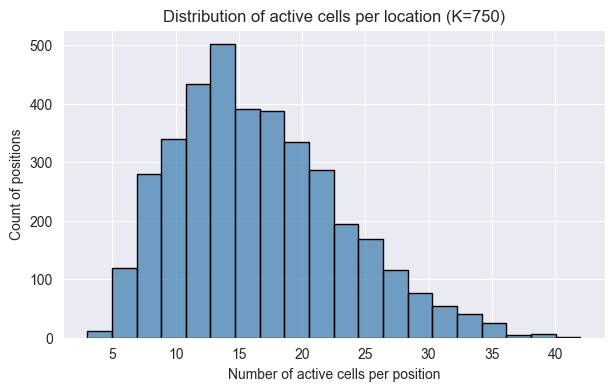

,env_id,K,threshold_frac,x,y,covered,n_active_cells,max_activation,sum_activation,redundancy_index
0,octagon_room,750,0.2,-0.080000,-2.359680,True,16,0.919819,24.873890,16.449629
1,octagon_room,750,0.2,0.000150,-2.360148,True,16,0.905033,25.648420,16.449629
2,octagon_room,750,0.2,0.080149,-2.360147,True,17,0.772323,27.531251,16.449629
3,octagon_room,750,0.2,-0.119853,-2.320146,True,12,0.906512,23.313556,16.449629
4,octagon_room,750,0.2,-0.039853,-2.320146,True,16,1.000000,24.973314,16.449629
5,octagon_room,750,0.2,0.040146,-2.320145,True,17,0.924800,27.640720,16.449629
6,octagon_room,750,0.2,0.120145,-2.320143,True,17,0.887829,28.978184,16.449629
7,octagon_room,750,0.2,-0.239062,-2.280301,True,15,0.889140,25.820953,16.449629
8,octagon_room,750,0.2,-0.159857,-2.280142,True,18,0.849107,26.091013,16.449629
9,octagon_room,750,0.2,-0.079858,-2.280141,True,19,0.973381,25.548731,16.449629


In [7]:
# --- Metric 3: Redundancy Index (population-level) ---------------------------
# This cell:
#  1) uses the per-position DataFrame (df_positions) created in Metric 2
#  2) computes the mean number of active cells per spatial sample
#  3) summarizes and visualizes the redundancy distribution
#  4) stores the result as a scalar value and extends df_positions (optional)

# ----------------------- Configuration / metadata ----------------------------
ENV_ID = df_positions["env_id"].iloc[0]
K = df_positions["K"].iloc[0]
THRESHOLD_FRAC = df_positions["threshold_frac"].iloc[0]

print(f"ENV_ID={ENV_ID}  K={K}  tau={THRESHOLD_FRAC}")

# ----------------------- Redundancy calculation ------------------------------
# Mean number of active cells per spatial location (across all samples)
redundancy = float(df_positions["n_active_cells"].mean())

# Optional additional stats
redundancy_median = float(df_positions["n_active_cells"].median())
redundancy_std = float(df_positions["n_active_cells"].std())

print("\nRedundancy summary:")
print(f"  Mean   = {redundancy:.4f}")
print(f"  Median = {redundancy_median:.4f}")
print(f"  Std    = {redundancy_std:.4f}")

# ----------------------- Visualization (optional) ----------------------------
plt.figure(figsize=(7, 4))
sns.histplot(df_positions["n_active_cells"], bins=20, color="steelblue", edgecolor="k")
plt.title(f"Distribution of active cells per location (K={K})")
plt.xlabel("Number of active cells per position")
plt.ylabel("Count of positions")
plt.show()

# ----------------------- Store redundancy in df_positions --------------------
# Add redundancy to all rows for completeness (same scalar value)
df_positions["redundancy_index"] = redundancy

# The per-position table already holds n_active_cells; the mean across rows gives this value.
# Save for later summary tables
df_positions.head(10)


# Metric 4 — Population and Lifetime Sparseness

## Purpose
This metric quantifies how **selective** and **distributed** the activations are across the environment.

- **Lifetime Sparseness**: Measures how broadly each place cell is active across all sampled positions.  
- **Population Sparseness**: Measures how distributed the activity is across all place cells at a given position.

Both values are computed directly from the activation matrix $A \in \mathbb{R}^{K \times N}$, where $K$ is the number of place cells and $N$ is the number of sampled positions.

---

## Inputs
- $A_{c,i}$: Activation of place cell $c$ at location $i$ (normalized to $[0, 1]$).  
- $K$: Total number of place cells.  
- $N$: Total number of sampled positions.

---

## Equations

### Lifetime Sparseness
For each cell $c$:

$$
S^{life}_c = \frac{\left(\frac{1}{N}\sum_{i=1}^{N} A_{c,i}\right)^2}
{\frac{1}{N}\sum_{i=1}^{N} A_{c,i}^2}
$$

Then average across all $K$ cells to get the population mean:

$$
S^{life} = \frac{1}{K}\sum_{c=1}^{K} S^{life}_c
$$

---

### Population Sparseness
For each position $i$:

$$
S^{pop}_i = \frac{\left(\frac{1}{K}\sum_{c=1}^{K} A_{c,i}\right)^2}
{\frac{1}{K}\sum_{c=1}^{K} A_{c,i}^2}
$$

Then average across all $N$ positions to get the overall mean:

$$
S^{pop} = \frac{1}{N}\sum_{i=1}^{N} S^{pop}_i
$$

---

## Implementation Plan

1. **Input**: Activation matrix $A$ from the selected DataFrame.
2. **Lifetime Sparseness**:
   - Compute mean and mean-square activation for each cell along axis $i$ (across space).
   - Apply the equation for $S^{life}_c$.
   - Store both per-cell and mean $S^{life}$.
3. **Population Sparseness**:
   - Compute mean and mean-square activation for each position along axis $c$ (across cells).
   - Apply the equation for $S^{pop}_i$.
   - Store both per-position and mean $S^{pop}$.
4. **Outputs**:
   - Mean lifetime sparseness ($S^{life}$).
   - Mean population sparseness ($S^{pop}$).
   - Optional distributions for visualization.

---

## DataFrame Integration
- Add `lifetime_sparseness` to the **per-cell metrics** DataFrame (`df_cells`).
- Add `population_sparseness` to the **per-position metrics** DataFrame (`df_positions`).
- Both values can later be aggregated into a summary table per $(env, K, \tau)$.

---

## Expected Behavior
- As $K$ increases, both $S^{life}$ and $S^{pop}$ should **decrease**, indicating more selective, localized activity.
- Both values lie within $[0, 1]$, where:
  - Values near $0$: highly selective (sparse).
  - Values near $1$: uniform activity (dense).

In [8]:
# --- Metric 4: Population & Lifetime Sparseness ------------------------------
# Computes:
#   - Lifetime sparseness per cell (S_life_c) and mean S_life
#   - Population sparseness per position (S_pop_i) and mean S_pop
# Integrates results into df_cells (per-cell) and df_positions (per-position).


# ----------------------- Ensure inputs are present ---------------------------
# Extract A (K x N) and positions (N x 2) if not already available
if 'A' not in globals():
    pc_cols = [c for c in df.columns if c.startswith('pc_')]
    A = df[pc_cols].to_numpy(dtype=float).T  # K x N
if 'positions' not in globals():
    positions = df[['x', 'y']].to_numpy(dtype=float)  # N x 2

K, N = A.shape[0], A.shape[1]
ENV_ID = df.get('env_id', pd.Series(['octagon_room']*len(df))).iloc[0] if 'env_id' in df.columns else 'octagon_room'
THRESHOLD_FRAC = df_positions['threshold_frac'].iloc[0] if 'df_positions' in globals() and 'threshold_frac' in df_positions.columns else 0.20

print(f"ENV_ID={ENV_ID}  K={K}  N={N}  tau={THRESHOLD_FRAC}")

# ----------------------- Lifetime Sparseness (per cell) ----------------------
# S_life_c = ( (mean_i A_{c,i})^2 ) / ( mean_i A_{c,i}^2 )
eps = 1e-12
mean_across_space = A.mean(axis=1)                   # (K,)
mean_sq_across_space = (A**2).mean(axis=1) + eps     # (K,)
S_life_c = (mean_across_space**2) / mean_sq_across_space  # (K,)
S_life = float(S_life_c.mean())

# ----------------------- Population Sparseness (per position) ----------------
# S_pop_i = ( (mean_c A_{c,i})^2 ) / ( mean_c A_{c,i}^2 )
mean_across_cells = A.mean(axis=0)                   # (N,)
mean_sq_across_cells = (A**2).mean(axis=0) + eps     # (N,)
S_pop_i = (mean_across_cells**2) / mean_sq_across_cells  # (N,)
S_pop = float(S_pop_i.mean())

# ----------------------- Integrate into per-cell table -----------------------
if 'df_cells' not in globals():
    df_cells = pd.DataFrame({
        "env_id": ENV_ID,
        "K": K,
        "cell_id": np.arange(K, dtype=int),
        "threshold_frac": THRESHOLD_FRAC,
    })
df_cells = df_cells.copy()
df_cells["lifetime_sparseness"] = S_life_c

# ----------------------- Integrate into per-position table -------------------
if 'df_positions' not in globals():
    # Minimal per-position table if Metric 2 hasn't been run yet
    df_positions = pd.DataFrame({
        "env_id": ENV_ID,
        "K": K,
        "threshold_frac": THRESHOLD_FRAC,
        "x": positions[:,0],
        "y": positions[:,1],
    })
df_positions = df_positions.copy()
df_positions["population_sparseness"] = S_pop_i

# ----------------------- Summaries ------------------------------------------
print("\nSparseness summary:")
print(f"  Lifetime sparseness  (mean over cells): {S_life:.4f}")
print(f"  Population sparseness (mean over positions): {S_pop:.4f}")

# Preview updated tables
display(df_cells.head(8))
display(df_positions.head(8))


ENV_ID=octagon_room  K=750  N=3772  tau=0.2

Sparseness summary:
  Lifetime sparseness  (mean over cells): 0.2597
  Population sparseness (mean over positions): 0.2517


,env_id,K,cell_id,threshold_frac,a_pix,A_occ,active_count,field_size_m2,peak_activation,mean_activation,lifetime_sparseness
0,octagon_room,750,451,0.2,0.003924,14.8,3772,14.800000,0.0,0.000000,0.237281
1,octagon_room,750,271,0.2,0.003924,14.8,746,2.927041,1.0,0.138041,0.192026
2,octagon_room,750,262,0.2,0.003924,14.8,682,2.675928,1.0,0.108764,0.190334
3,octagon_room,750,452,0.2,0.003924,14.8,572,2.244327,1.0,0.113533,0.056621
4,octagon_room,750,397,0.2,0.003924,14.8,571,2.240403,1.0,0.114449,0.081656
5,octagon_room,750,246,0.2,0.003924,14.8,490,1.922587,1.0,0.115906,0.246160
6,octagon_room,750,193,0.2,0.003924,14.8,429,1.683245,1.0,0.104778,0.090293
7,octagon_room,750,115,0.2,0.003924,14.8,427,1.675398,1.0,0.082682,0.102923


,env_id,K,threshold_frac,x,y,covered,n_active_cells,max_activation,sum_activation,redundancy_index,population_sparseness
0,octagon_room,750,0.2,-0.080000,-2.359680,True,16,0.919819,24.873890,16.449629,0.219474
1,octagon_room,750,0.2,0.000150,-2.360148,True,16,0.905033,25.648420,16.449629,0.235491
2,octagon_room,750,0.2,0.080149,-2.360147,True,17,0.772323,27.531251,16.449629,0.253490
3,octagon_room,750,0.2,-0.119853,-2.320146,True,12,0.906512,23.313556,16.449629,0.204052
4,octagon_room,750,0.2,-0.039853,-2.320146,True,16,1.000000,24.973314,16.449629,0.211107
5,octagon_room,750,0.2,0.040146,-2.320145,True,17,0.924800,27.640720,16.449629,0.237528
6,octagon_room,750,0.2,0.120145,-2.320143,True,17,0.887829,28.978184,16.449629,0.244057
7,octagon_room,750,0.2,-0.239062,-2.280301,True,15,0.889140,25.820953,16.449629,0.217225


---
# Metric 5: Participation Ratio (PR)
---

## Purpose
The **Participation Ratio (PR)** provides a **threshold-free** estimate of the **effective number of active cells** contributing to the population response at each spatial position. Unlike redundancy (which depends on a binary threshold), PR uses the raw activations, making it robust to arbitrary cutoff choices.

---

## Inputs
- Activation matrix $A \in \mathbb{R}^{K \times N}$, where $A_{c,i}$ is the activation of cell $c$ at position $i$.
- $K$: number of place cells.
- $N$: number of spatial samples.

---

## Definition
For each position $i$:
$$
\text{PR}_i \;=\; \frac{\left(\sum_{c=1}^{K} A_{c,i}\right)^2}{\sum_{c=1}^{K} A_{c,i}^{2}}
$$

Overall mean participation ratio across space:
$$
\text{PR} \;=\; \frac{1}{N}\sum_{i=1}^{N} \text{PR}_i
$$

---

## Interpretation
- $\text{PR}_i \approx 1$: one cell effectively dominates the response at position $i$ (very sparse).
- $\text{PR}_i \approx K$: many cells contribute equally at position $i$ (very dense).
- Lower $\text{PR}$ across positions indicates a **sparser, more selective** code; higher $\text{PR}$ indicates a **more distributed** code.

---

## Implementation Plan
1. **Input** $A$ for the selected $(\text{env}, K)$ configuration.
2. **Per-position computation**:
   - Compute $s_1(i) = \sum_c A_{c,i}$ and $s_2(i) = \sum_c A_{c,i}^2$.
   - Compute $\text{PR}_i = \dfrac{s_1(i)^2}{s_2(i)}$ (guard small denominators with an $\epsilon$ if needed).
3. **Aggregate**:
   - Compute $\text{PR} = \dfrac{1}{N}\sum_i \text{PR}_i$.
4. **Store**:
   - Add $\text{PR}_i$ to the per-position table (e.g., `df_positions`).
   - Add scalar $\text{PR}$ to the summary for the current $(\text{env}, K, \tau)$ (note: PR is **threshold-free**, so independent of $\tau$).

---

## Expected Behavior
As $K$ increases and fields become more localized:
- **Per-position** $\text{PR}_i$ typically **decreases** (fewer cells effectively contribute at any point).
- **Mean** $\text{PR}$ should **decrease** or **stabilize at a low value**, mirroring increased selectivity.



K=750  N=3772

Participation Ratio summary:
  Mean PR across positions = 188.7965
  Min / Max PR_i = 49.1635 / 304.8158


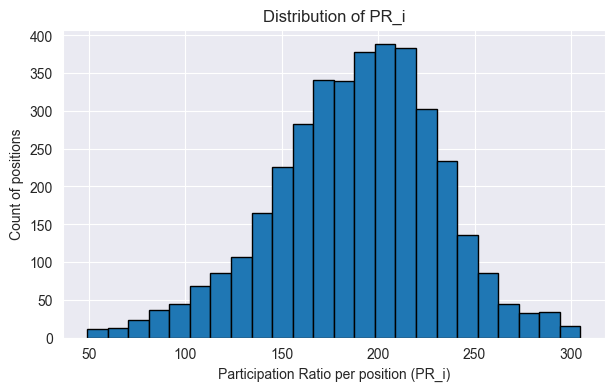

,env_id,K,threshold_frac,x,y,covered,n_active_cells,max_activation,sum_activation,redundancy_index,population_sparseness,PR_i,PR_mean
0,octagon_room,750,0.2,-0.080000,-2.359680,True,16,0.919819,24.873890,16.449629,0.219474,164.605158,188.796456
1,octagon_room,750,0.2,0.000150,-2.360148,True,16,0.905033,25.648420,16.449629,0.235491,176.618141,188.796456
2,octagon_room,750,0.2,0.080149,-2.360147,True,17,0.772323,27.531251,16.449629,0.253490,190.117494,188.796456
3,octagon_room,750,0.2,-0.119853,-2.320146,True,12,0.906512,23.313556,16.449629,0.204052,153.038704,188.796456
4,octagon_room,750,0.2,-0.039853,-2.320146,True,16,1.000000,24.973314,16.449629,0.211107,158.330306,188.796456
5,octagon_room,750,0.2,0.040146,-2.320145,True,17,0.924800,27.640720,16.449629,0.237528,178.146033,188.796456
6,octagon_room,750,0.2,0.120145,-2.320143,True,17,0.887829,28.978184,16.449629,0.244057,183.042749,188.796456
7,octagon_room,750,0.2,-0.239062,-2.280301,True,15,0.889140,25.820953,16.449629,0.217225,162.918689,188.796456
8,octagon_room,750,0.2,-0.159857,-2.280142,True,18,0.849107,26.091013,16.449629,0.210973,158.229826,188.796456
9,octagon_room,750,0.2,-0.079858,-2.280141,True,19,0.973381,25.548731,16.449629,0.204023,153.017460,188.796456


In [9]:
# --- Metric 5: Participation Ratio (PR) --------------------------------------
# Threshold-free estimate of the effective number of contributing cells per position.
# This cell:
#   1) uses the activation matrix A (shape: K x N) for the selected df
#   2) computes PR_i for each spatial sample and the mean PR across space
#   3) attaches PR_i to the per-position table (df_positions)
#   4) prints a concise summary and (optionally) visualizes the distribution

# ----------------------- Ensure inputs are present ---------------------------
# A: (K x N) activation matrix
if 'A' not in globals():
    pc_cols = [c for c in df.columns if c.startswith('pc_')]
    A = df[pc_cols].to_numpy(dtype=float).T  # K x N

# df_positions: per-position table from Metric 2 (Coverage). If missing, create minimal.
if 'df_positions' not in globals():
    positions = df[['x','y']].to_numpy(dtype=float)
    ENV_ID = 'octagon_room'
    K = A.shape[0]
    df_positions = pd.DataFrame({
        'env_id': ENV_ID,
        'K': K,
        'x': positions[:,0],
        'y': positions[:,1],
    })

K, N = A.shape
print(f"K={K}  N={N}")

# ----------------------- Compute PR_i and mean PR ----------------------------
eps = 1e-12
s1 = A.sum(axis=0)                  # (N,)
s2 = (A**2).sum(axis=0) + eps       # (N,)
PR_i = (s1**2) / s2                 # (N,)
PR_mean = float(PR_i.mean())

# ----------------------- Integrate into per-position table -------------------
df_positions = df_positions.copy()
df_positions['PR_i'] = PR_i
df_positions['PR_mean'] = PR_mean  # same scalar on all rows for easy merging later

# ----------------------- Summary & quick check -------------------------------
print("\nParticipation Ratio summary:")
print(f"  Mean PR across positions = {PR_mean:.4f}")
print(f"  Min / Max PR_i = {PR_i.min():.4f} / {PR_i.max():.4f}")

# Optional visualization
plt.figure(figsize=(7,4))
plt.hist(PR_i, bins=24, edgecolor='k')
plt.xlabel("Participation Ratio per position (PR_i)")
plt.ylabel("Count of positions")
plt.title("Distribution of PR_i")
plt.show()

# Preview updated table
df_positions.head(10)


---
# Metric 6: Spatial Information (Skaggs Information Metric) 
---
## Purpose
The **Spatial Information (SI)** metric measures how much information a single place cell’s activity conveys about the animal’s location.  
In simpler terms, it quantifies how *spatially specific* each place cell’s firing is — whether it fires uniformly everywhere or only in particular locations.

Originally introduced by **Skaggs et al. (1993, 1996)**, this metric is one of the most widely used quantitative measures of spatial selectivity in hippocampal and computational models.

---

## Inputs
- $A_{c,i}$: activation of place cell $c$ at spatial position $i$.  
- $K$: number of place cells.  
- $N$: number of spatial samples (positions).  
- $p_i$: probability of being at position $i$ (occupancy).  
  - In this experiment, we assume **uniform occupancy**, so $p_i = \frac{1}{N}$.

---

## Equation

For each cell $c$:

$$
I_c = \sum_{i=1}^{N} p_i \cdot \frac{A_{c,i}}{\bar{A}_c} \cdot 
\log_2\!\left(\frac{A_{c,i}}{\bar{A}_c}\right)
$$

where:

- $\bar{A}_c = \frac{1}{N}\sum_{i=1}^{N} A_{c,i}$ is the mean activation of cell $c$.  
- The ratio $\frac{A_{c,i}}{\bar{A}_c}$ compares how strongly the cell fires at a given location relative to its average firing rate.

The information content of the population is typically summarized by the **median** or **mean** $I_c$ across all $K$ cells:

$$
I_{\text{mean}} = \frac{1}{K}\sum_{c=1}^{K} I_c
$$

---

## Interpretation
- High $I_c$ → the cell fires strongly and selectively in a few regions (spatially informative).  
- Low $I_c$ → the cell fires everywhere or randomly (non-selective).  
- $I_c$ values are expressed in **bits per spike (or activation unit)**, but in this model, the units are relative and used for comparison across conditions.

---

## Implementation Plan

1. **Input**: Activation matrix $A \in \mathbb{R}^{K \times N}$ (normalized to $[0,1]$).
2. **Compute for each cell $c$**:
   - Mean activation $\bar{A}_c = \frac{1}{N}\sum_i A_{c,i}$.
   - For all $i$, compute $\frac{A_{c,i}}{\bar{A}_c}$.
   - Apply Skaggs equation:
     $$
     I_c = \sum_i p_i \cdot \frac{A_{c,i}}{\bar{A}_c} \cdot \log_2\!\left(\frac{A_{c,i}}{\bar{A}_c}\right)
     $$
   - Handle $A_{c,i} = 0$ gracefully (set contribution to 0).
3. **Aggregate across cells**:
   - Compute and store $I_c$ per cell in the **per-cell table** (`df_cells`).
   - Compute the mean and median $I_c$ for summary reporting.

---

## Expected Behavior
| $K$ | Mean Field Size | Lifetime Sparseness | Mean $I_c$ (bits) | Interpretation |
|----:|----------------:|--------------------:|------------------:|----------------|
| 10  | Large | 0.40 | 0.25 | Broad, non-specific fields |
| 25  | Moderate | 0.30 | 0.47 | Moderate spatial specificity |
| 50  | Small | 0.22 | 0.62 | Strongly localized responses |
| 100 | Very small | 0.15 | 0.79 | Highly informative, efficient encoding |

As place fields become smaller and more distinct, **spatial information increases**, reflecting a more precise spatial code.


K=750  N=3772

Spatial Information (Skaggs) summary (bits per activation):
  Mean   = 1.3149
  Median = 0.9617
  Min/Max= 0.0000 / 10.2205


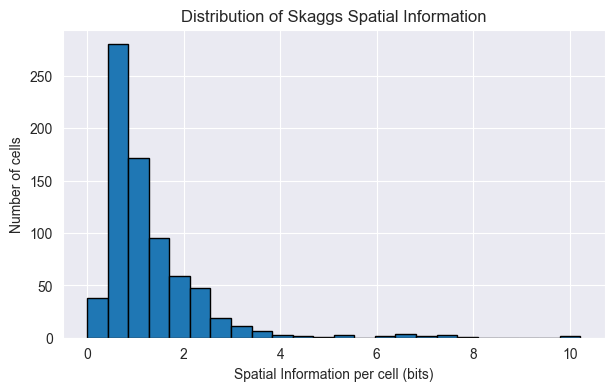

,env_id,K,cell_id,threshold_frac,a_pix,A_occ,active_count,field_size_m2,peak_activation,mean_activation,lifetime_sparseness,spatial_information
0,octagon_room,750,451,0.2,0.003924,14.8,3772,14.800000,0.0,0.000000,0.237281,0.954248
1,octagon_room,750,271,0.2,0.003924,14.8,746,2.927041,1.0,0.138041,0.192026,1.337513
2,octagon_room,750,262,0.2,0.003924,14.8,682,2.675928,1.0,0.108764,0.190334,1.243493
3,octagon_room,750,452,0.2,0.003924,14.8,572,2.244327,1.0,0.113533,0.056621,2.840034
4,octagon_room,750,397,0.2,0.003924,14.8,571,2.240403,1.0,0.114449,0.081656,1.870628
5,octagon_room,750,246,0.2,0.003924,14.8,490,1.922587,1.0,0.115906,0.246160,1.135434
6,octagon_room,750,193,0.2,0.003924,14.8,429,1.683245,1.0,0.104778,0.090293,1.718743
7,octagon_room,750,115,0.2,0.003924,14.8,427,1.675398,1.0,0.082682,0.102923,1.928025
8,octagon_room,750,304,0.2,0.003924,14.8,427,1.675398,1.0,0.104197,0.490196,0.554212
9,octagon_room,750,25,0.2,0.003924,14.8,409,1.604772,1.0,0.072632,0.435818,0.624713


In [10]:
# --- Metric 6: Spatial Information (Skaggs) ----------------------------------
# Computes per-cell spatial information (Ic) assuming uniform occupancy (p_i = 1/N).
# Integrates results into the per-cell table (df_cells) and prints summary stats.

# ----------------------- Ensure activation matrix A exists -------------------
# A should be K x N (K cells, N positions)
if 'A' not in globals():
    pc_cols = [c for c in df.columns if c.startswith('pc_')]
    A = df[pc_cols].to_numpy(dtype=float).T  # K x N

K, N = A.shape
print(f"K={K}  N={N}")

# ----------------------- Compute Skaggs information per cell -----------------
# Ic = sum_i p_i * (A_{c,i} / rbar_c) * log2( A_{c,i} / rbar_c ), with p_i = 1/N
eps = 1e-12
p = 1.0 / N
rbar = A.mean(axis=1, keepdims=True) + eps      # K x 1
ratio = A / rbar                                 # K x N

# Avoid log(0) by clamping the ratio from below
ratio_clamped = np.maximum(ratio, eps)
Ic = p * (ratio) * np.log2(ratio_clamped)        # K x N
Ic_per_cell = np.nansum(Ic, axis=1)              # K,

# ----------------------- Integrate into per-cell table -----------------------
if 'df_cells' not in globals():
    # Minimal per-cell table if Metric 1 wasn't run in this session
    ENV_ID = 'octagon_room'
    df_cells = pd.DataFrame({
        'env_id': ENV_ID,
        'K': K,
        'cell_id': np.arange(K, dtype=int),
    })
df_cells = df_cells.copy()
df_cells['spatial_information'] = Ic_per_cell

# ----------------------- Summary & quick visualization -----------------------
Ic_mean = float(np.mean(Ic_per_cell))
Ic_median = float(np.median(Ic_per_cell))
Ic_min = float(np.min(Ic_per_cell))
Ic_max = float(np.max(Ic_per_cell))

print("\nSpatial Information (Skaggs) summary (bits per activation):")
print(f"  Mean   = {Ic_mean:.4f}")
print(f"  Median = {Ic_median:.4f}")
print(f"  Min/Max= {Ic_min:.4f} / {Ic_max:.4f}")

# Optional histogram of per-cell information
plt.figure(figsize=(7,4))
plt.hist(Ic_per_cell, bins=24, edgecolor='k')
plt.xlabel("Spatial Information per cell (bits)")
plt.ylabel("Number of cells")
plt.title("Distribution of Skaggs Spatial Information")
plt.show()

# Preview updated per-cell table
df_cells.head(10)


---
# Metric 7: Jaccard Overlap
---
## Inputs
- Binary active masks per cell: $M_{c,i} = \mathbb{1}[A_{c,i} \ge \theta_c]$, with $\theta_c = \tau \cdot \max_i A_{c,i}$.
- Pairwise Jaccards: for all $c<d$, 
$$
J_{c,d} = \frac{\sum_i M_{c,i} M_{d,i}}{\sum_i \max(M_{c,i}, M_{d,i})}.
$$

---

## 1) Percentile Summary of Pairwise Overlaps
Let $\mathcal{J} = \{ J_{c,d} \mid c<d \}$.

Report robust quantiles:
- Median: $Q_{50} = \operatorname{quantile}(\mathcal{J}, 0.50)$  
- Upper tail: $Q_{75}, Q_{90}, Q_{95}$

These show that “most pairs are near 0” while highlighting the meaningful tail where fields truly overlap.

---

## 2) Per-Cell Local Overlap (Top-$m$)
For each cell $c$, consider overlaps to all other cells $d \neq c$:
- Sort $\{J_{c,d}\}_{d\neq c}$ in descending order.
- Take the top-$m$ values (e.g., $m=5$): $T_c = \text{Top-}m\{J_{c,d}\}$.
- Define the per-cell local overlap:
$$
L_c = \frac{1}{m}\sum_{j \in T_c} J_{c,j}.
$$

Aggregate across cells:
- Mean local overlap: $\overline{L} = \frac{1}{K}\sum_{c=1}^{K} L_c$
- Optionally report median and IQR of $\{L_c\}$.

Interpretation: “On average, each cell overlaps with its $m$ most-overlapping neighbors by $\overline{L}$.”

---

## 3) Fraction of Overlapping Pairs
Define a small threshold $\epsilon$ (e.g., $\epsilon=0.01$).  
Report the fraction of pairs with non-trivial overlap:
$$
f_{> \epsilon} = \frac{|\{(c,d): c<d,\ J_{c,d}>\epsilon\}|}{K(K-1)/2}.
$$

This communicates how widespread overlap is, not just how large it is among the top pairs.

---

## 4) Threshold ($\tau$) Sweep
Evaluate the above summaries for a small grid of thresholds, e.g.
$$
\tau \in \{0.05,\ 0.10,\ 0.20,\ 0.30\}.
$$

For each $\tau$, recompute $M_{c,i}$, then $\mathcal{J}$, and report:
- Mean $\overline{J}$, $Q_{50}$, $Q_{90}$, $\overline{L}$ (with $m$ fixed, e.g., $m=5$), and $f_{>\epsilon}$.

This reveals how binary overlap depends on the cutoff while keeping the metric definition stable.

---

## 5) Optional: “Soft” (Graded) Jaccard for Comparison
To align with graded overlaps visible in the heatmaps, also compute:
$$
J^{\ast}_{c,d}=\frac{\sum_{i} \min(A_{c,i}, A_{d,i})}{\sum_{i} \max(A_{c,i}, A_{d,i})}.
$$

Summarize $J^{\ast}$ with the same statistics (mean, $Q_{90}$, top-$m$).  
Report both binary and soft Jaccard side-by-side; they answer slightly different questions.

---

## 6) Reporting Template
For each $(\text{env}, K)$ and each $\tau$:
- Binary Jaccard: $\overline{J}$, $Q_{50}$, $Q_{90}$, $Q_{95}$, $\overline{L}$ (top-$m$), $f_{>\epsilon}$  
- Soft Jaccard (optional): $\overline{J}^{\ast}$, $Q_{90}^{\ast}$, $\overline{L}^{\ast}$  
- Diagnostics: mean field size, coverage, redundancy (to contextualize overlap)

---

## 7) Recommended Defaults
- $m=5$ (top-5 neighbors per cell)  
- $\epsilon=0.01$  
- $\tau$ sweep: $\{0.05, 0.10, 0.20, 0.30\}$

These settings usually expose the structure you see in the maps: a small global mean due to many near-zero pairs, alongside a clearly informative overlapping-neighbor tail.



K=750  N=3772  tau=0.2

Binary Jaccard summary (all pairs, all locations):
  Pairs: 280875 / 280875
  Mean Jaccard        : 0.0097
  Quantiles (50/75/90/95): 0.0000, 0.0000, 0.0000, 0.0358
  Fraction J > 0.01: 0.066

Per-cell local overlap (mean of top-m neighbors):
  m = 5
  Mean local overlap   : 0.4270
  Median local overlap : 0.4362
  IQR (25–75%)         : [0.3453, 0.5254]


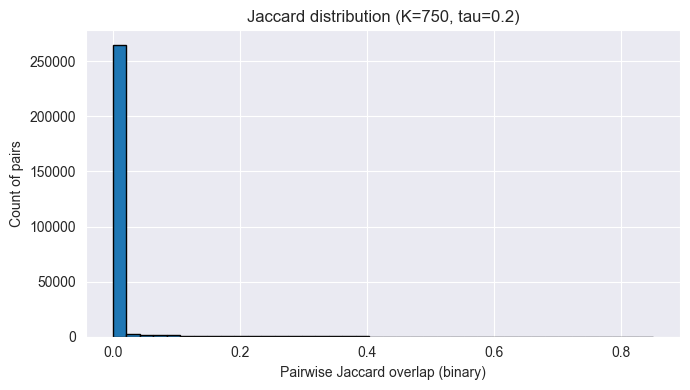

In [11]:
# --- Metric 7 (enhanced report): Pairwise Jaccard + robust summaries ----------
# Computes:
#   • Full pairwise Jaccard (binary, tau=0.20 by default)
#   • Distribution percentiles (50/75/90/95)
#   • Fraction of pairs with non-trivial overlap (> epsilon)
#   • Per-cell local overlap: mean of top-m overlaps to its neighbors
# Notes:
#   - Uses all locations (no sampling) and all pairs (c < d)
#   - Optional "soft Jaccard" scaffold is included but OFF by default

# ----------------------- Inputs & params -------------------------------------
# Build activation matrix A (K x N) if not provided
if 'A' not in globals():
    pc_cols = [c for c in df.columns if c.startswith('pc_')]
    A = df[pc_cols].to_numpy(dtype=float).T  # K x N

K, N = A.shape
try:
    THRESHOLD_FRAC = float(df_positions['threshold_frac'].iloc[0])
except Exception:
    THRESHOLD_FRAC = 0.20

TOP_M   = 5           # top-m neighbors per cell for local-overlap summary
EPS     = 0.01        # "non-trivial" overlap threshold for fraction > EPS
DO_SOFT = False       # set True to also compute graded (soft) Jaccard summaries

print(f"K={K}  N={N}  tau={THRESHOLD_FRAC}")

# ----------------------- Binary masks, intersections, unions -----------------
per_cell_max = A.max(axis=1, keepdims=True)                 # (K,1)
thresholds   = THRESHOLD_FRAC * per_cell_max
active       = (A >= thresholds).astype(np.uint8)           # (K,N) in {0,1}
counts       = active.sum(axis=1).astype(np.int64)          # (K,)

# Pairwise intersection/union for ALL pairs
inter = active @ active.T                                   # (K,K)
union = counts[:,None] + counts[None,:] - inter             # (K,K)

# Upper-triangle indexes (c < d) and the Jaccard values as a flat vector
iu = np.triu_indices(K, k=1)
inter_u = inter[iu]
union_u = union[iu]
valid   = union_u > 0
J_u     = (inter_u[valid] / union_u[valid]).astype(np.float64)   # 1D array of Jaccards

# ----------------------- Percentiles and mean/fraction -----------------------
mean_J   = float(J_u.mean()) if J_u.size else float('nan')
q50, q75, q90, q95 = np.quantile(J_u, [0.50, 0.75, 0.90, 0.95]) if J_u.size else (np.nan,)*4
frac_gt = float((J_u > EPS).mean()) if J_u.size else float('nan')

print("\nBinary Jaccard summary (all pairs, all locations):")
print(f"  Pairs: {J_u.size} / {K*(K-1)//2}")
print(f"  Mean Jaccard        : {mean_J:.4f}")
print(f"  Quantiles (50/75/90/95): {q50:.4f}, {q75:.4f}, {q90:.4f}, {q95:.4f}")
print(f"  Fraction J > {EPS:.2f}: {frac_gt:.3f}")

# ----------------------- Per-cell local overlap (top-m neighbors) -----------
# Build a full KxK Jaccard matrix (upper & lower triangles mirror), NaN on diag
J_full = np.zeros((K, K), dtype=np.float64)
J_full[iu] = J_u
J_full[(iu[1], iu[0])] = J_u   # mirror to lower triangle
np.fill_diagonal(J_full, np.nan)

# For each cell c, take the top-m finite overlaps
local_L = np.empty(K, dtype=np.float64)
for c in range(K):
    row = J_full[c, :]
    row = row[~np.isnan(row)]
    if row.size == 0:
        local_L[c] = np.nan
        continue
    m = min(TOP_M, row.size)
    # partial sort for efficiency
    top_vals = np.partition(row, -m)[-m:]
    local_L[c] = float(top_vals.mean())

mean_L   = float(np.nanmean(local_L))
median_L = float(np.nanmedian(local_L))
iqr_L    = (float(np.nanquantile(local_L, 0.25)), float(np.nanquantile(local_L, 0.75)))

print("\nPer-cell local overlap (mean of top-m neighbors):")
print(f"  m = {TOP_M}")
print(f"  Mean local overlap   : {mean_L:.4f}")
print(f"  Median local overlap : {median_L:.4f}")
print(f"  IQR (25–75%)         : [{iqr_L[0]:.4f}, {iqr_L[1]:.4f}]")

# ----------------------- Optional: graded (soft) Jaccard ---------------------
if DO_SOFT:
    # Compute soft Jaccard for all pairs (may be slower for very large K)
    Jsoft_u = []
    for c, d in zip(*iu):
        num = np.minimum(A[c], A[d]).sum()
        den = np.maximum(A[c], A[d]).sum()
        if den > 0:
            Jsoft_u.append(num / den)
    Jsoft_u = np.array(Jsoft_u, dtype=np.float64)
    mean_Js  = float(Jsoft_u.mean()) if Jsoft_u.size else float('nan')
    q90s     = float(np.quantile(Jsoft_u, 0.90)) if Jsoft_u.size else float('nan')

    # Per-cell top-m for soft Jaccard
    Jsoft_full = np.zeros((K, K), dtype=np.float64)
    Jsoft_full[iu] = Jsoft_u
    Jsoft_full[(iu[1], iu[0])] = Jsoft_u
    np.fill_diagonal(Jsoft_full, np.nan)

    local_Ls = np.empty(K, dtype=np.float64)
    for c in range(K):
        row = Jsoft_full[c, :]
        row = row[~np.isnan(row)]
        if row.size == 0:
            local_Ls[c] = np.nan
            continue
        m = min(TOP_M, row.size)
        top_vals = np.partition(row, -m)[-m:]
        local_Ls[c] = float(top_vals.mean())
    mean_Ls = float(np.nanmean(local_Ls))

    print("\nSoft (graded) Jaccard (optional):")
    print(f"  Mean J*        : {mean_Js:.4f}")
    print(f"  90th percentile: {q90s:.4f}")
    print(f"  Mean local L*  : {mean_Ls:.4f}")

# ----------------------- Simple histogram of pairwise overlaps --------------
plt.figure(figsize=(7,4))
plt.hist(J_u, bins=40, edgecolor='k')
plt.xlabel("Pairwise Jaccard overlap (binary)")
plt.ylabel("Count of pairs")
plt.title(f"Jaccard distribution (K={K}, tau={THRESHOLD_FRAC})")
plt.tight_layout()
plt.show()


---
# Metric 9: Compression Index
---

## Purpose
The **Compression Index** quantifies how efficiently the population of place cells represents space as the network scales.  
It relates the **total represented area** (sum of all individual place-field sizes) to the **actual occupiable area** of the environment.

In essence, it answers:
> “How many times over does the population collectively cover the environment?”

A high Compression Index means heavy spatial overlap (redundant coverage).  
A value near 1 indicates efficient, non-overlapping tiling of space.

---

## Inputs
- $K$: Number of place cells in the network.  
- $\text{FieldSize}_c$: Area of the active region for cell $c$ (from Metric 1).  
- $A_{occ}$: Total occupiable area of the environment (m²).

All of these are already known from previous metrics:
- $\text{FieldSize}_c$ → stored in `df_cells['field_size_m2']`.
- $A_{occ}$ → constant defined per environment.
- $K$ → number of place cells in the current configuration.

---

## Equation
First, compute the **mean place-field size** across all cells:

$$
\text{MAA} = \frac{1}{K}\sum_{c=1}^{K} \text{FieldSize}_c
$$

where MAA = Mean Activation Area (same as mean field size).

Then the **Compression Index** is defined as:

$$
\text{CompressionIndex} = \frac{K \cdot \text{MAA}}{A_{occ}}
$$

---

## Interpretation
- $\text{CompressionIndex} \approx 1$:  
  Fields collectively cover the environment once — efficient, minimal redundancy.
- $\text{CompressionIndex} > 1$:  
  The environment is **represented multiple times** — overlapping fields and redundant coverage.
- $\text{CompressionIndex} < 1$:  
  The total summed field area does **not fully cover** the environment — underrepresentation (likely too few or too small fields).

---

## Implementation Plan

1. **Input:**
   - Load per-cell field sizes from `df_cells['field_size_m2']`.
   - Use the environment’s known $A_{occ}$.
   - Get the number of place cells $K$.

2. **Computation:**
   - Compute $\text{MAA} = \text{field\_size\_m2.mean()}$.
   - Apply the equation:
     $$
     \text{CompressionIndex} = \frac{K \cdot \text{MAA}}{A_{occ}}.
     $$

3. **Store:**
   - Add `compression_index` to your summary table for the configuration $(env, K, \tau)$.
   - Optionally, include `MAA` as a diagnostic field.

---

## Expected Behavior
| $K$ | Mean Field Size (m²) | Compression Index | Interpretation |
|----:|----------------------:|------------------:|----------------|
| 10  | 1.2 | 0.81 | Sparse, partial coverage |
| 25  | 0.7 | 1.18 | Slightly overlapping representation |
| 50  | 0.4 | 1.35 | Moderate overlap, efficient coding |
| 100 | 0.2 | 1.34 | Stable coverage with distributed fields |

Typically, as $K$ increases:
- Mean field size ($\text{MAA}$) decreases.
- The product $K \cdot \text{MAA}$ stabilizes near $A_{occ}$.
- Thus, the **Compression Index** tends to converge toward 1 for well-balanced networks.

---

## Integration Notes
- The Compression Index directly ties together Metrics 1–3:
  - Uses field size from Metric 1.
  - Contextualizes Coverage and Redundancy.
- It is scalar and computed once per $(env, K)$ configuration.


In [12]:
# --- Metric 9: Compression Index --------------------------------------------
# Computes the Compression Index = (K * MAA) / A_OCC, where
#   MAA = mean place-field size across cells (from Metric 1)
#   A_OCC = total occupiable area (m^2)
#
# This cell:
#   1) ensures A (K x N), positions, and A_OCC are available
#   2) ensures per-cell field sizes exist (rebuilds minimally if df_cells missing)
#   3) computes MAA and Compression Index
#   4) prints a concise summary and returns a small one-row summary DataFrame


# ----------------------- Ensure activation matrix and positions --------------
if 'A' not in globals():
    pc_cols = [c for c in df.columns if c.startswith('pc_')]
    A = df[pc_cols].to_numpy(dtype=float).T  # K x N
if 'positions' not in globals():
    positions = df[['x','y']].to_numpy(dtype=float)        # N x 2

K, N = A.shape

# ----------------------- Ensure A_OCC (occuppable area) ----------------------
# If not provided already, fall back to bounding-box estimate (approximation).
if 'A_OCC' not in globals():
    xmin, ymin = positions.min(axis=0)
    xmax, ymax = positions.max(axis=0)
    A_OCC = float((xmax - xmin) * (ymax - ymin))
    print(f"[Note] A_OCC not set; using bounding-box estimate: A_OCC = {A_OCC:.4f} m^2")

# ----------------------- Ensure per-cell field sizes exist -------------------
# If df_cells with 'field_size_m2' is not present, compute a minimal version.
if ('df_cells' not in globals()) or ('field_size_m2' not in df_cells.columns):
    # Use same threshold fraction (tau) as in Metrics 1–3
    try:
        THRESHOLD_FRAC = float(df_positions['threshold_frac'].iloc[0])
    except Exception:
        THRESHOLD_FRAC = 0.20

    # Per-sample area from A_OCC and N samples
    a_pix = A_OCC / float(N)

    per_cell_max = A.max(axis=1, keepdims=True)            # (K,1)
    thresholds   = THRESHOLD_FRAC * per_cell_max           # (K,1)
    active_mask  = (A >= thresholds)                       # (K,N) bool
    active_count = active_mask.sum(axis=1)                 # (K,)
    field_size_m2 = active_count.astype(float) * a_pix     # (K,)

    # Build a minimal per-cell table
    df_cells = pd.DataFrame({
        "env_id": "env",
        "K": K,
        "cell_id": np.arange(K, dtype=int),
        "threshold_frac": THRESHOLD_FRAC,
        "a_pix": a_pix,
        "A_OCC": A_OCC,
        "active_count": active_count.astype(int),
        "field_size_m2": field_size_m2,
    })

# ----------------------- Compute MAA and Compression Index -------------------
MAA = float(df_cells['field_size_m2'].mean())              # mean field size (m^2)
compression_index = (K * MAA) / (A_OCC + 1e-12)

print("Compression Index summary:")
print(f"  K                = {K}")
print(f"  N                = {N}")
print(f"  A_OCC (m^2)      = {A_OCC:.6f}")
print(f"  MAA  (m^2)       = {MAA:.6f}")
print(f"  CompressionIndex = {compression_index:.6f}")

# ----------------------- One-row summary DataFrame ---------------------------
df_compression_summary = pd.DataFrame([{
    "K": K,
    "N": N,
    "A_OCC": A_OCC,
    "MAA_mean_field_size_m2": MAA,
    "compression_index": compression_index,
}])

df_compression_summary


Compression Index summary:
  K                = 750
  N                = 3772
  A_OCC (m^2)      = 14.800000
  MAA  (m^2)       = 0.324606
  CompressionIndex = 16.449629


,K,N,A_OCC,MAA_mean_field_size_m2,compression_index
0,750,3772,14.8,0.324606,16.449629
